# Ejercicio Ridge, Lasso y ElasticNet
Para este ejercicio vas a trabajar con datos de ventas de una empresa que fabrica muebles en España. Esta empresa es una Pyme que demanda conocer de antemano qué ingresos va a tener cada mes, ya que necesita pedir un anticipio a su entidad financiera de cara a poder abastecerse de materia prima al comenzar el mes. Como desconoce cuánto tiene que pedir, tira al alza y acaba pagando muchos intereses. El objetivo es reducir estos gastos.

En las bases de datos de la empresa constan todos los gastos en publicidad y ventas, para cada uno de los meses desde su fundación (hace más de 15 años).

Dado que los presupuestos de marketing se cierran al principio de cada mes, la empresa necesita un modelo predictivo que le anticipe las ventas que conseguirá a final de mes en función de los gastos que realizará en marketing.

Para ello tendrás que utilizar tanto modelos de regresión normales, como regularizados.

1. Carga los datos y realiza un pequeño análisis exploratorio. Mira a ver cómo se relaciona las ventas con el resto de variables.
2. Crea varios modelos y modifica los hiperparámetros necesarios para mejorar el performance del modelo.
3. Interpreta los resultados. Traduce a una fórmula tu mejor modelo (escribir la fórmula simplemente). ¿Cuánto cambian las ventas si aumentamos la inversión en radio un punto más? ¿Y si aumentamos la inversión en TV o periódicos?

## Import libraries 

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Exploratory Data Analysis 

In [ ]:
# Lectura datos, relación variables, mapas de correlación...

In [2]:
import glob
glob.glob("data/*")

['data\\Advertising.csv']

In [87]:
df = pd.read_csv("data/Advertising.csv")
df

,Unnamed: 0,TV,radio,newpaper,sales
0,0,230.1,37.8,6s9.2,22100.0
1,1,44.5,39.3,45.1,10400.0
2,2,17.2,45.9,69.3,9300.0
3,3,151.5,41.3,58.5,18500.0
4,4,180.8,10.8,58.4,12900.0
...,...,...,...,...,...
195,195,38.2,3.7,13.8,7600.0
196,196,94.2,4.9,8.1,9700.0
197,197,177.0,9.3,6.4,12800.0
198,198,283.6,42.0,66.2,25500.0


In [88]:
df.drop(columns="Unnamed: 0", inplace=True)
df

,TV,radio,newpaper,sales
0,230.1,37.8,6s9.2,22100.0
1,44.5,39.3,45.1,10400.0
2,17.2,45.9,69.3,9300.0
3,151.5,41.3,58.5,18500.0
4,180.8,10.8,58.4,12900.0
...,...,...,...,...
195,38.2,3.7,13.8,7600.0
196,94.2,4.9,8.1,9700.0
197,177.0,9.3,6.4,12800.0
198,283.6,42.0,66.2,25500.0


In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   TV        200 non-null    float64
 1   radio     200 non-null    float64
 2   newpaper  200 non-null    str    
 3   sales     200 non-null    float64
dtypes: float64(3), str(1)
memory usage: 7.1 KB


In [90]:
df=df[1:]
df

,TV,radio,newpaper,sales
1,44.5,39.3,45.1,10400.0
2,17.2,45.9,69.3,9300.0
3,151.5,41.3,58.5,18500.0
4,180.8,10.8,58.4,12900.0
5,8.7,48.9,75.0,7200.0
...,...,...,...,...
195,38.2,3.7,13.8,7600.0
196,94.2,4.9,8.1,9700.0
197,177.0,9.3,6.4,12800.0
198,283.6,42.0,66.2,25500.0


In [91]:
df['newpaper'] = df.newpaper.astype(float)

In [92]:
df.dtypes

TV          float64
radio       float64
newpaper    float64
sales       float64
dtype: object

In [93]:
df.describe()

,TV,radio,newpaper,sales
count,199.000000,199.000000,199.000000,199.000000
mean,146.625126,23.190955,30.359799,13981.909548
std,85.867111,14.848182,21.659246,5198.861022
min,0.700000,0.000000,0.300000,1600.000000
25%,74.050000,9.950000,12.700000,10350.000000
50%,149.700000,22.500000,25.600000,12900.000000
75%,218.450000,36.400000,44.700000,17350.000000
max,296.400000,49.600000,114.000000,27000.000000


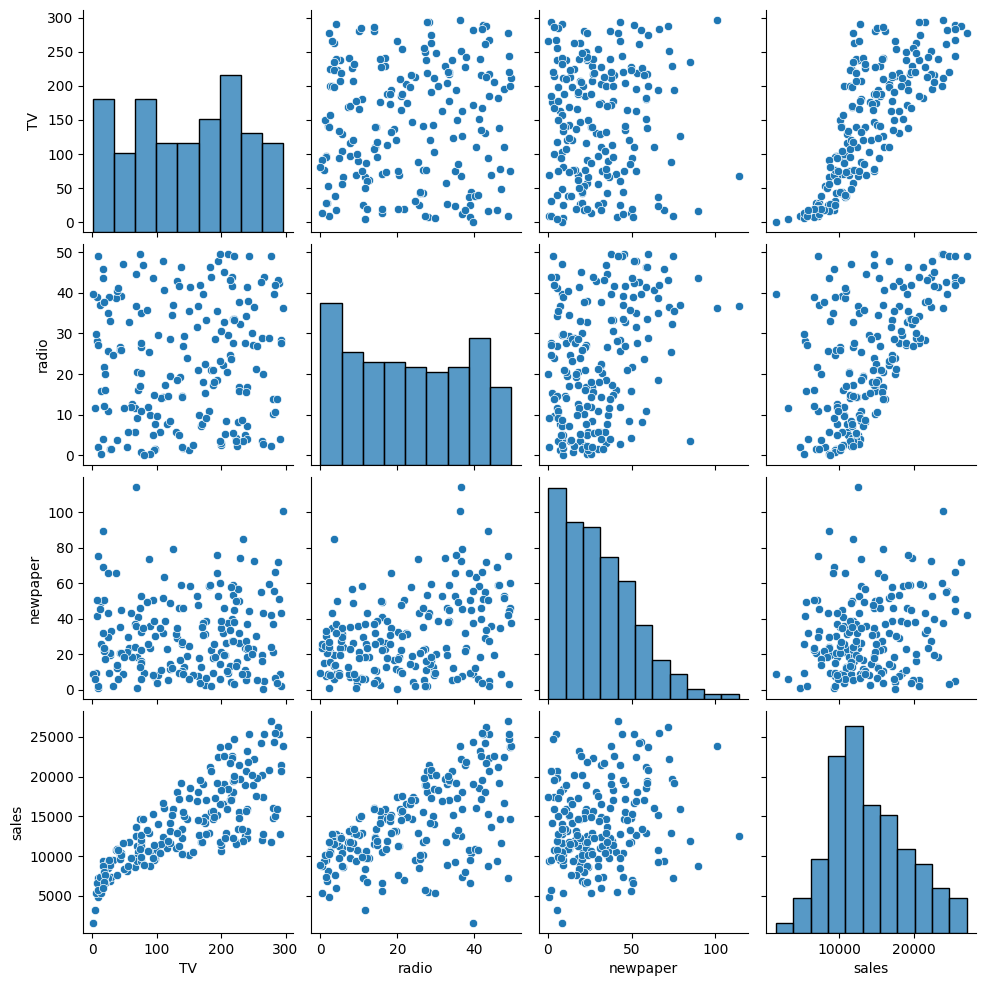

In [94]:
sns.pairplot(df);

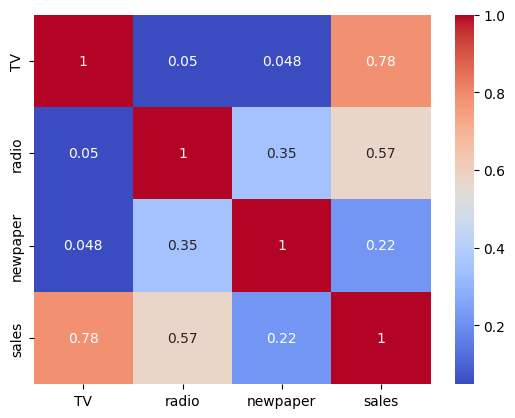

In [95]:
sns.heatmap(df.corr(), annot= True, cmap="coolwarm");

## Modelado

In [237]:
# Manipulación datasets, entrenamiento, evaluación, nuevas iteraciones... Prueba modelos sin y con regularización.

In [96]:
X = df[['TV', 'radio', 'newpaper']].to_numpy()
y = df['sales'].to_numpy()

In [97]:
X.shape

(199, 3)

In [98]:
y.shape

(199,)

In [99]:
np.random.seed(42) # implanto semilla

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Create scalers
scaler_X = StandardScaler()
scaler_y = StandardScaler() # NO HAY QUE

# 3. Fit ONLY on training data, FIT DONDE LA TANGENTE ES 0
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# y must be 2D for StandardScaler
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

In [101]:
y_test_scaled.shape

(40, 1)

In [102]:
y_train_scaled.shape

(159, 1)

In [ ]:
# LINEAR REGRESSION

In [105]:
# creo modelo

from sklearn import linear_model, metrics
from sklearn.metrics import mean_absolute_percentage_error

lr = linear_model.LinearRegression()

lr.fit(X_train, y_train)

y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

baseline_error = metrics.mean_squared_error(y_test, y_test_pred)

print("Train MSE:", metrics.mean_squared_error(y_train, y_train_pred))
print("Test MSE:", metrics.mean_squared_error(y_test, y_test_pred))
print("Test RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))

print("Train MAPE:", mean_absolute_percentage_error(y_train, y_train_pred) * 100)
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_test_pred) * 100)

# print("Test R2:", r2_score(y_test, y_test_pred(X_test)))
# print("Test R2:", r2_score(y_train, y_train_pred(X_train)))

Train MSE: 2872614.923945353
Test MSE: 2520107.8401506124
Test RMSE: 1587.4847527301206
Train MAPE: 14.505339125691869
Test MAPE: 12.085771842296273


In [ ]:
# train 14% de error y 12% de error el test

In [54]:
# Ridge

# Ridge model (L2 regularization)
lr = linear_model.Ridge(alpha=0.5)  # you can tune alpha

lr.fit(X_train, y_train)

y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

baseline_error = metrics.mean_squared_error(y_test, y_test_pred)

print("Train MSE:", metrics.mean_squared_error(y_train, y_train_pred))
print("Test MSE:", metrics.mean_squared_error(y_test, y_test_pred))
print("Test RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))

print("Train MAPE:", mean_absolute_percentage_error(y_train, y_train_pred) * 100)
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_test_pred) * 100)

Train MSE: 2976044.788561327
Test MSE: 2513774.4075074745
Test RMSE: 1585.488696745415
Train MAPE: 15.316940403789722
Test MAPE: 10.932495187396455


In [55]:
n_alphas = 100
alphas = np.logspace(-4, 3, n_alphas) 

coef_ridge = []
err_ridge = []
baseline = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    
    coef_ridge.append(ridge.coef_)
    
    y_pred = ridge.predict(X_test)
    ridge_error = metrics.mean_squared_error(y_pred, y_test)
    
    err_ridge.append(ridge_error)
    baseline.append(baseline_error)

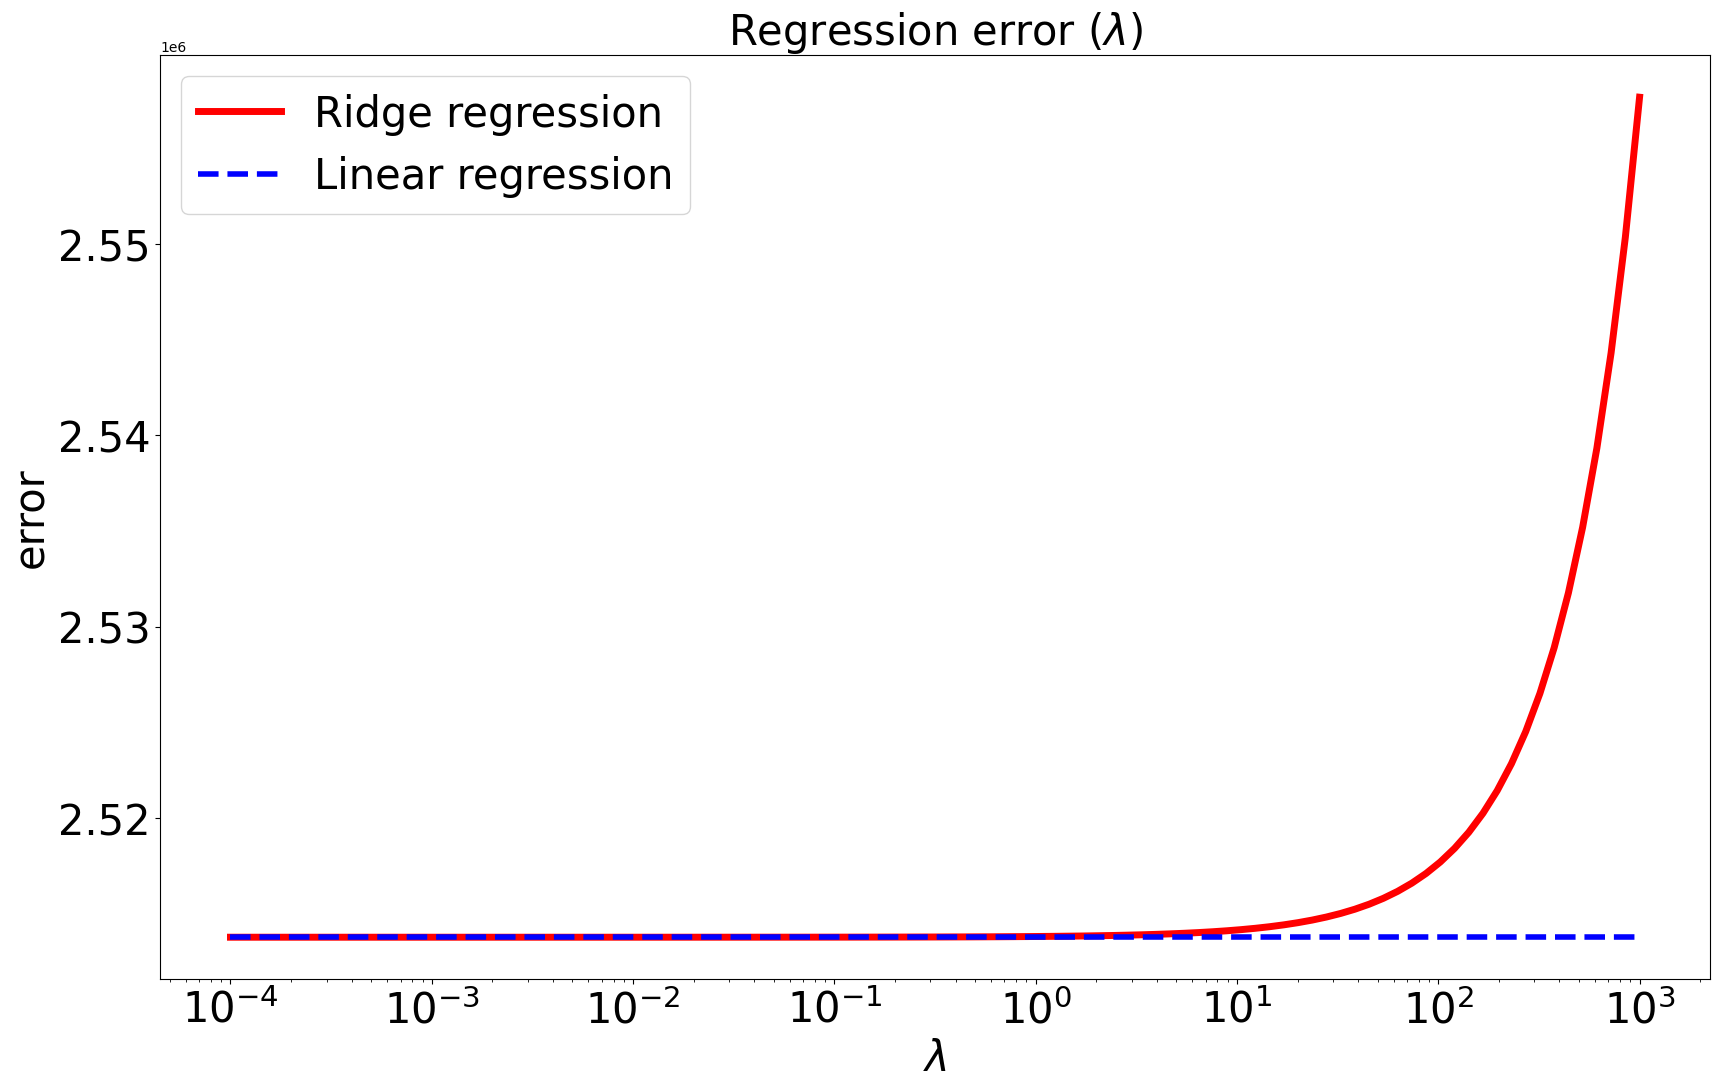

In [56]:
plt.figure(figsize=(20,12))
ax = plt.gca()
ax.plot(alphas, err_ridge, linewidth=5, color='red', label="Ridge regression")
ax.plot(alphas, baseline, linewidth=4,linestyle='--', color='blue', label='Linear regression')
ax.set_xscale('log')
plt.xlabel(r'$\lambda$', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylabel('error', fontsize=30)
ax.legend(fontsize=30)
plt.title(r'Regression error ($\lambda$)', fontsize=30)
plt.show()

In [57]:
from sklearn.linear_model import Lasso

lassoR = Lasso(alpha=0.1)
lassoR.fit(X_train, y_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(y_train, lr.predict(X_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(y_test, lr.predict(X_test)),2))

print("Train MSE: %0.4f" % metrics.mean_squared_error(y_train, lassoR.predict(X_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(y_test, lassoR.predict(X_test)))

Train MSE sin regularización: 2976044.79
Test MSE sin regularización: 2513774.41
Train MSE: 2976044.7864
Test MSE: 2513754.3477


In [58]:
from sklearn.linear_model import Lasso

lassoR = Lasso(alpha=0.05)
lassoR.fit(X_train, y_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(y_train, lr.predict(X_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(y_test, lr.predict(X_test)),2))

print("Train MSE: %0.4f" % metrics.mean_squared_error(y_train, lassoR.predict(X_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(y_test, lassoR.predict(X_test)))

Train MSE sin regularización: 2976044.79
Test MSE sin regularización: 2513774.41
Train MSE: 2976044.7863
Test MSE: 2513754.9876


In [59]:
lasso = linear_model.Lasso(fit_intercept=False)

coef_lasso = []
err_lasso = []

for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X_train, y_train)
    coef_lasso.append(lasso.coef_)
    y_pred = lasso.predict(X_test)
    lasso_error = metrics.mean_squared_error(y_pred, y_test)    
    err_lasso.append(lasso_error)

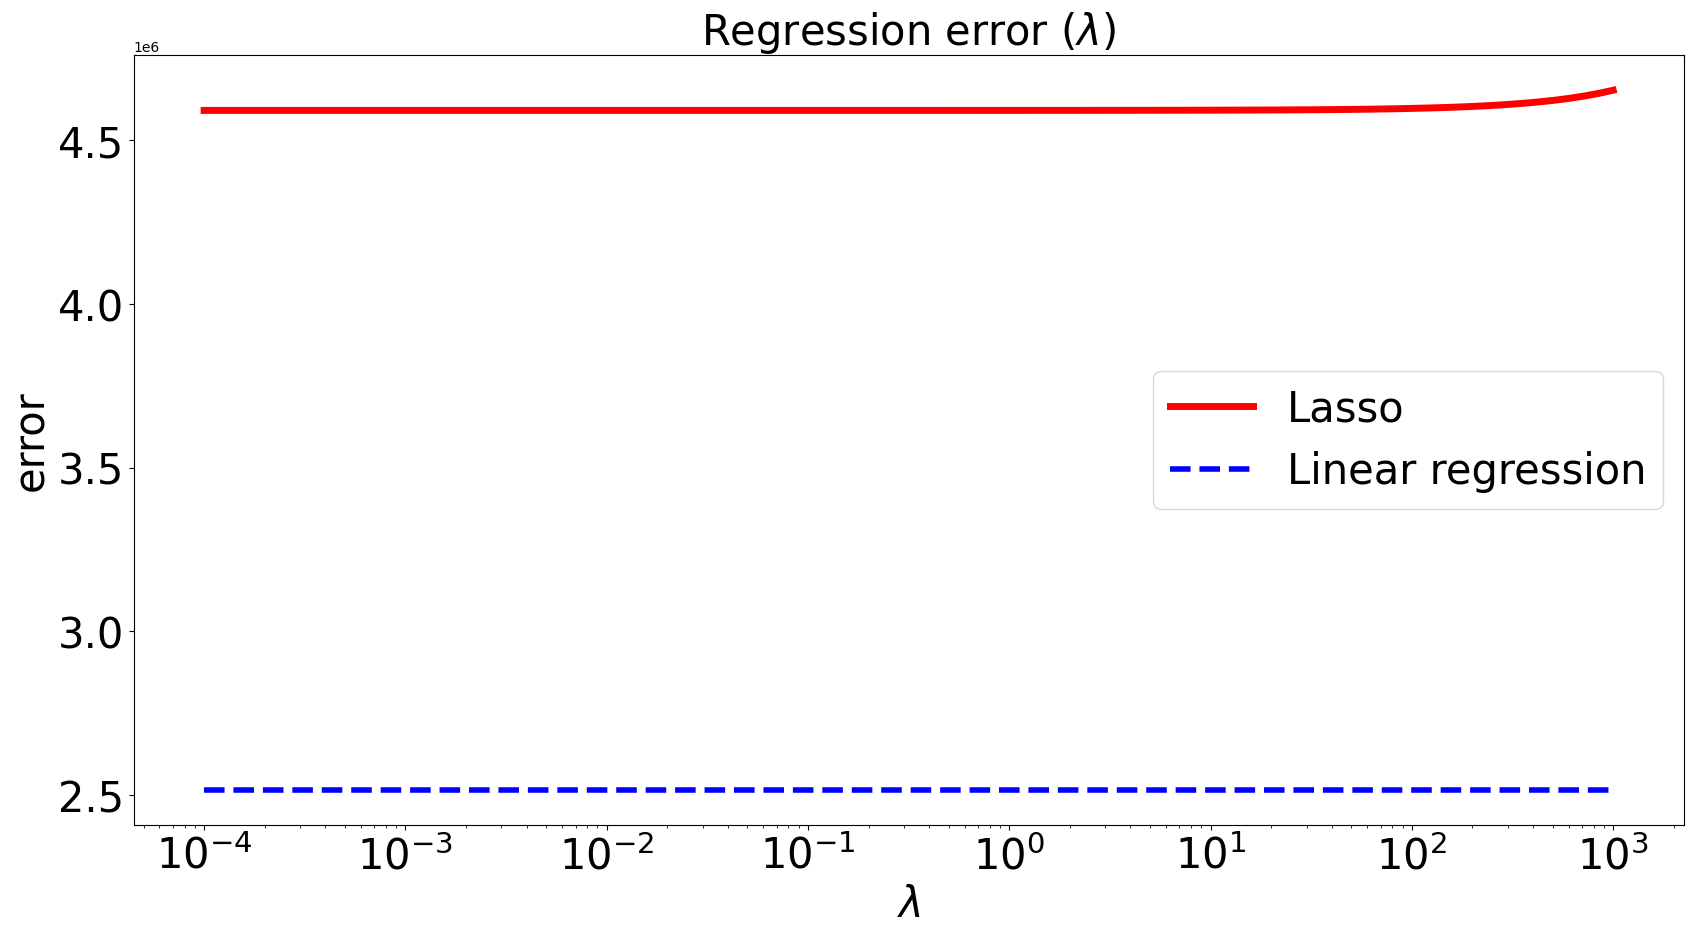

In [60]:
plt.figure(figsize=(20,10))
ax = plt.gca()
ax.plot(alphas, err_lasso, linewidth=5, color='red', label="Lasso")
ax.plot(alphas, baseline, linewidth=4,linestyle='--', color='blue', label='Linear regression')
ax.set_xscale('log')
plt.xlabel(r'$\lambda$', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylabel('error', fontsize=30)
ax.legend(fontsize=30)
plt.title(r'Regression error ($\lambda$)', fontsize=30)
plt.show()

In [ ]:
# si no funciona con uno ni con otro , tampoco funcionará con la combinación

In [ ]:
# elastic net

In [61]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha = 1, l1_ratio = 0.5)
elastic_net.fit(X_train, y_train)

print("Train MSE: %0.4f" % metrics.mean_squared_error(y_train, elastic_net.predict(X_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(y_test, elastic_net.predict(X_test)))

Train MSE: 2976087.9554
Test MSE: 2516408.1460


In [62]:
coef_eln = []
err_eln = []
baseline = []
for a in alphas:
    elastic_net = ElasticNet(alpha = a, l1_ratio=0.5)
    elastic_net.fit(X_train, y_train)
    coef_eln.append(elastic_net.coef_)
    y_pred = elastic_net.predict(X_test)
    elasticnet_error = metrics.mean_squared_error(y_pred, y_test)
    err_eln.append(elasticnet_error)
    baseline.append(baseline_error)
    

In [63]:
min(err_eln)

2513755.7815568456

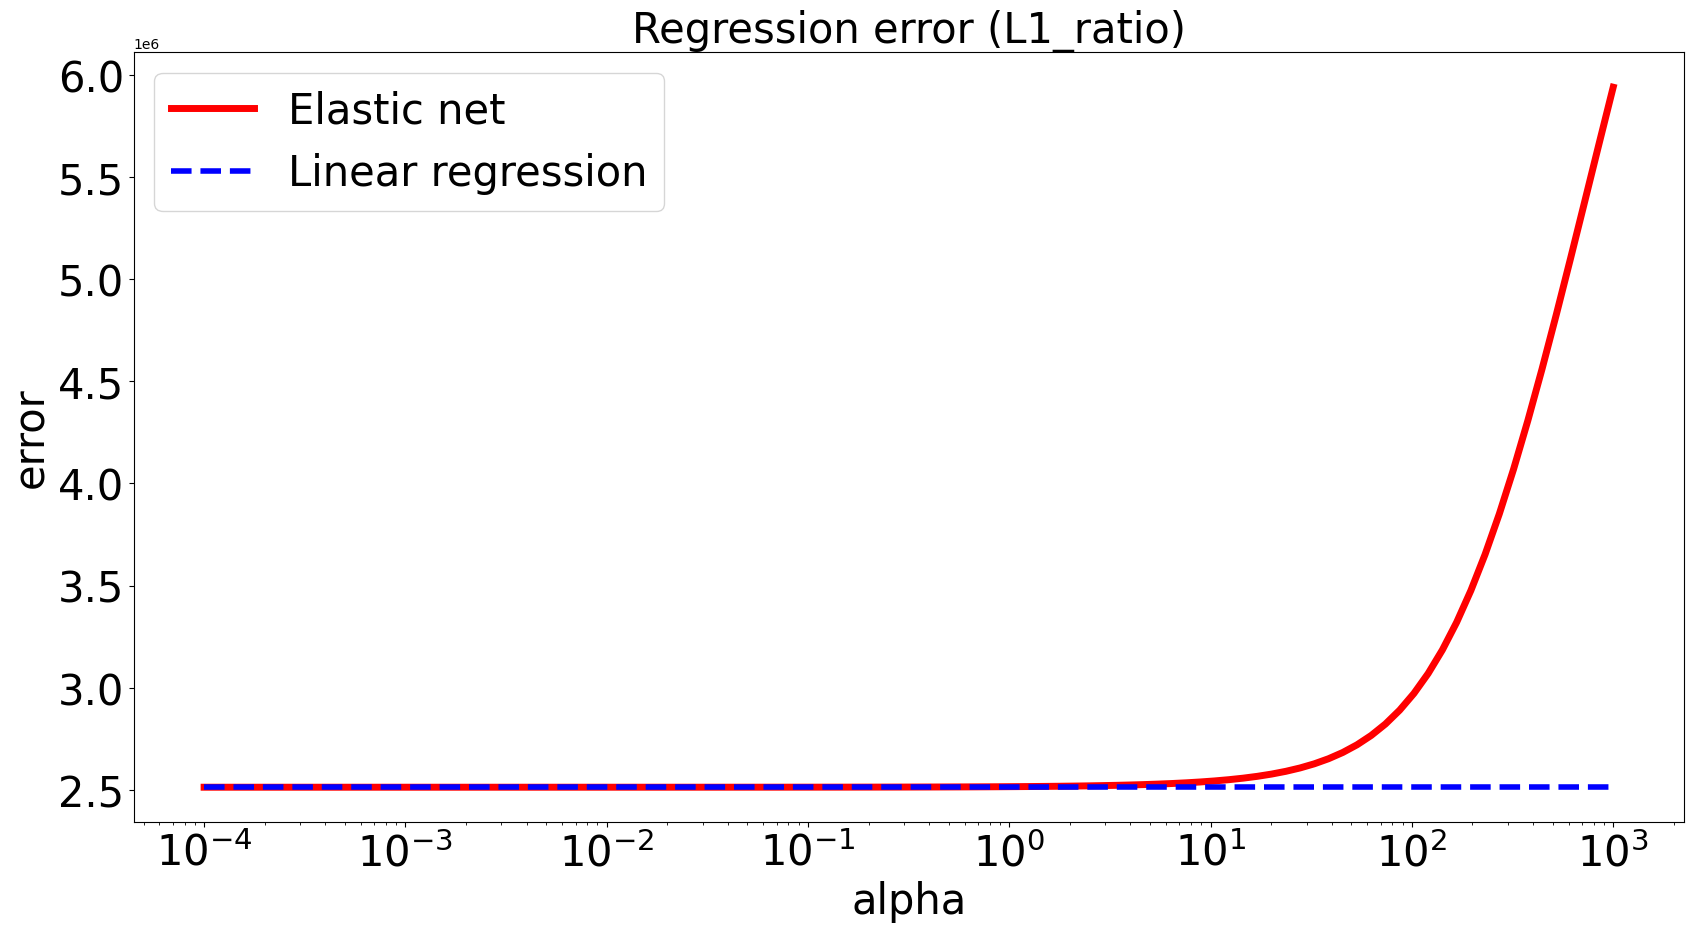

In [64]:
plt.figure(figsize=(20,10))
ax = plt.gca()
ax.plot(alphas, err_eln, linewidth=5, color='red', label="Elastic net")
ax.plot(alphas, baseline, linewidth=4,linestyle='--', color='blue', label='Linear regression')
ax.set_xscale('log')
plt.xlabel('alpha', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylabel('error', fontsize=30)
ax.legend(fontsize=30)
plt.title(r'Regression error (L1_ratio)', fontsize=30)
plt.show()

In [ ]:
# el mejor modelo predictor es el linear regression

### Modelos Polinómicos

In [65]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
poly_feats = PolynomialFeatures(degree = 2)
poly_feats.fit(X)
X_poly = poly_feats.transform(X)

poly_X_train, poly_X_test, poly_y_train, poly_y_test = train_test_split(X_poly,y, test_size = 0.3, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(poly_X_train, poly_y_train)

predictions = lin_reg.predict(poly_X_test)

print("MAE:", mean_absolute_error(poly_y_test, predictions))
print("MAPE:", mean_absolute_percentage_error(poly_y_test, predictions))
print("MSE:", mean_squared_error(poly_y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(poly_y_test, predictions)))
print("r2_score train", lin_reg.score(poly_X_train, poly_y_train))
print("r2_score test",lin_reg.score(poly_X_test, poly_y_test))

# 1. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 2. Generación de características polinómicas
poly = PolynomialFeatures(degree=2)
poly_X_train = poly.fit_transform(X_train)
poly_X_test = poly.transform(X_test)

# 3. Entrenamiento del modelo
lin_reg = LinearRegression()
lin_reg.fit(poly_X_train, y_train)

# 4. Predicciones
predictions = lin_reg.predict(poly_X_test)

# 5. Métricas
print("MAE:", mean_absolute_error(y_test, predictions))
print("MAPE:", mean_absolute_percentage_error(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))
print("R2 train:", lin_reg.score(poly_X_train, y_train))
print("R2 test:", lin_reg.score(poly_X_test, y_test))



MAE: 15.846954219646175
MAPE: 1.597690573123073
MSE: 447.64385897942697
RMSE: 21.157595775026685
r2_score train 0.16338703993130332
r2_score test -0.00044825812682569577


In [79]:
# 1. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 2. Generación de características polinómicas
poly = PolynomialFeatures(degree=2)
poly_X_train = poly.fit_transform(X_train)
poly_X_test = poly.transform(X_test)

# 3. Entrenamiento del modelo
lin_reg = LinearRegression()
lin_reg.fit(poly_X_train, y_train)

# 4. Predicciones
predictions = lin_reg.predict(poly_X_test)

# 5. Métricas
print("MAE:", mean_absolute_error(y_test, predictions))
print("MAPE:", mean_absolute_percentage_error(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))
print("R2 train:", lin_reg.score(poly_X_train, y_train))
print("R2 test:", lin_reg.score(poly_X_test, y_test))


MAE: 15.846954219646175
MAPE: 1.597690573123073
MSE: 447.64385897942697
RMSE: 21.157595775026685
R2 train: 0.16338703993130332
R2 test: -0.00044825812682569577


In [ ]:
poly_feats = PolynomialFeatures(degree = 3)
poly_feats.fit(X_train)
X_poly = poly_feats.transform(X_train)

poly_X_train, poly_X_test, poly_y_train, poly_y_test = train_test_split(X_poly,y_train, test_size = 0.3, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(poly_X_train, poly_y_train)

predictions = lin_reg.predict(poly_X_test)

print("MAE:", mean_absolute_error(poly_y_test, predictions))
print("MAPE:", mean_absolute_percentage_error(poly_y_test, predictions))
print("MSE:", mean_squared_error(poly_y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(poly_y_test, predictions)))
print("r2_score train", lin_reg.score(poly_X_train, poly_y_train))
print("r2_score test",lin_reg.score(poly_X_test, poly_y_test))

MAE: 403.58445262959935
MAPE: 0.03152101820064094
MSE: 232701.7684655881
RMSE: 482.39171682937103
r2_score train 0.9924123334666287
r2_score test 0.99068608536074


## Resultados

In [269]:
# Interpreta, resume y destaca los puntos importantes de los resultados.

In [270]:
# Utiliza todas las celdas que necesites...

In [ ]:
# LOS MODELOS POLINÓMICOS PUEDEN MEJORAR EL RENDIMIENTO DE LOS MODELOS DE REGRESIÓN LINEAL, PERO HAY QUE TENER CUIDADO CON EL OVERFITTING. EN ESTE CASO, EL MODELO POLINÓMICO DE GRADO 2 MEJORA EL RENDIMIENTO EN COMPARACIÓN CON EL MODELO LINEAL, MIENTRAS QUE EL MODELO DE GRADO 3 NO MEJORA SIGNIFICATIVAMENTE Y PUEDE ESTAR SOBREAJUSTANDO LOS DATOS. ES IMPORTANTE EVALUAR LAS MÉTRICAS DE RENDIMIENTO Y REALIZAR VALIDACIÓN CRUZADA PARA SELECCIONAR EL MODELO MÁS ADECUADO.